# 6 · Optimal transport with a matrix-free operator

Optimal transport asks how to move mass from a source distribution $a$ to a target $b$ at
least cost. A **transport plan** is a nonnegative matrix $P \in \mathbb{R}^{n\times m}$ whose
row sums are $a$ and column sums are $b$:

$$ P\,\mathbf{1} = a, \qquad P^\top \mathbf{1} = b. $$

Those two constraints are a single **linear operator** acting on the plan,

$$ K : P \;\longmapsto\; (P\mathbf{1},\; P^\top\mathbf{1}), $$

and it would be wasteful to store it as an $(n+m)\times nm$ matrix. This is the perfect job
for a **`MatrixFreeLinOp`**: we give SpaceCore the forward action and its adjoint as two small
functions. We then solve entropic OT with the Sinkhorn algorithm, in which that operator's
**adjoint** is exactly the step that turns dual potentials into a transport plan.

**You will learn to** express marginalisation as a matrix-free operator, verify its adjoint,
and use it inside a real algorithm.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import spacecore as sc

# A clean, consistent palette + style for every figure in the tutorials.
BLUE, INDIGO, CYAN = "#2563eb", "#4f46e5", "#0891b2"
PINK, AMBER, GREEN = "#db2777", "#d97706", "#059669"
SLATE, GRID = "#334155", "#e5e9f0"

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2), "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": SLATE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": SLATE,
    "axes.labelcolor": SLATE, "axes.labelsize": 11,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.4, "lines.markersize": 6, "image.cmap": "magma",
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[BLUE, PINK, GREEN, AMBER, INDIGO, CYAN])

print("spacecore", sc.__version__, "| numpy", np.__version__)

spacecore 0.4.0 | numpy 2.4.2


In [2]:
ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)
ops = ctx.ops

## 1 · A source, a target, and a cost

We place $n$ source bins and $m$ target bins on the line $[0,1]$. The source is a single bump,
the target is bimodal. The cost to move a unit of mass from $x_i$ to $y_j$ is the squared
distance $C_{ij} = (x_i - y_j)^2$.

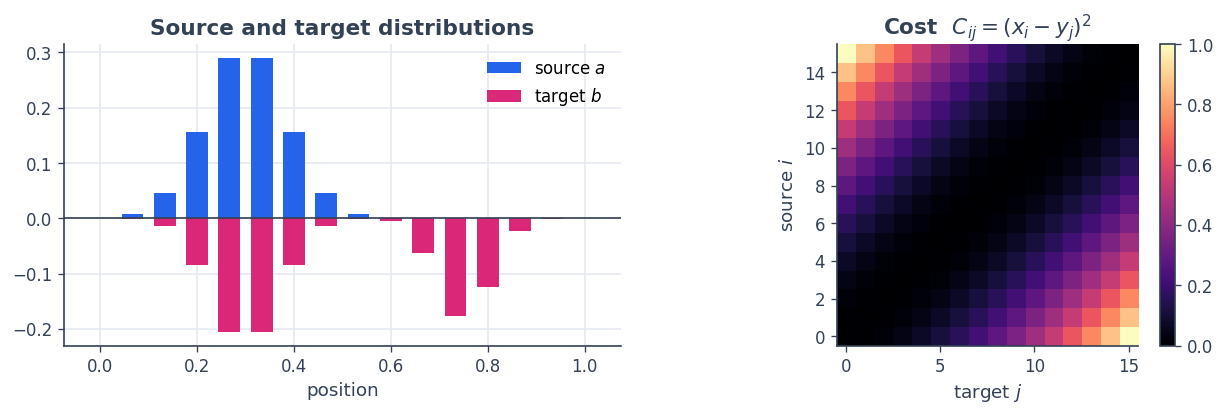

In [3]:
n, m = 16, 16
xs = np.linspace(0, 1, n)
ys = np.linspace(0, 1, m)

def normalize(v): return v / v.sum()
a = normalize(np.exp(-((xs - 0.30) / 0.12) ** 2))                       # source: one bump
b = normalize(np.exp(-((ys - 0.30) / 0.10) ** 2)
              + 0.8 * np.exp(-((ys - 0.75) / 0.08) ** 2))               # target: two bumps
Cmat = (xs[:, None] - ys[None, :]) ** 2                                 # cost matrix

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6))
axes[0].bar(xs, a, width=0.045, color=BLUE, label="source $a$")
axes[0].bar(ys, -b, width=0.045, color=PINK, label="target $b$")
axes[0].axhline(0, color=SLATE, lw=1); axes[0].set_title("Source and target distributions")
axes[0].set_xlabel("position"); axes[0].legend()
im = axes[1].imshow(Cmat, cmap="magma", origin="lower"); axes[1].grid(False)
axes[1].set_title("Cost  $C_{ij}=(x_i-y_j)^2$"); axes[1].set_xlabel("target $j$"); axes[1].set_ylabel("source $i$")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

## 2 · Marginalisation as a `MatrixFreeLinOp`

The plan lives in the matrix space $\mathbb{R}^{n\times m}$; the marginals live in
$\mathbb{R}^{n+m}$. The forward map stacks the row sums and column sums. Its **adjoint** is the
"broadcast" map that takes a vector $(\phi,\psi)$ and spreads it back over the matrix as
$\phi_i + \psi_j$ — the transpose of summation is tiling.

In [4]:
P_space = sc.DenseCoordinateSpace((n, m), ctx)      # transport plans
M_space = sc.DenseVectorSpace((n + m,), ctx)        # stacked marginals [row; col]

def marginals(P):                                   # forward:  P → (P1, Pᵀ1)
    return ops.concatenate([ops.sum(P, axis=1), ops.sum(P, axis=0)])

def broadcast(g):                                   # adjoint:  (φ, ψ) → φ_i + ψ_j
    return g[:n][:, None] + g[n:][None, :]

K = sc.MatrixFreeLinOp(marginals, broadcast, P_space, M_space, ctx)

# Verify the adjoint identity  <K P, g> = <P, K* g>  (no matrix ever formed)
rng = np.random.default_rng(0)
P_test = ctx.asarray(rng.standard_normal((n, m)))
g_test = ctx.asarray(rng.standard_normal(n + m))
lhs = float(M_space.inner(K.apply(P_test), g_test))
rhs = float(P_space.inner(P_test, K.rapply(g_test)))
print(f"<K P, g> = {lhs:.10f}")
print(f"<P, K*g> = {rhs:.10f}")
print("adjoint identity holds:", np.isclose(lhs, rhs))

<K P, g> = -1.8810878180
<P, K*g> = -1.8810878180
adjoint identity holds: True


## 3 · Sinkhorn, powered by the adjoint

Entropic OT solves $\min_P \langle C, P\rangle + \varepsilon\sum_{ij} P_{ij}\log P_{ij}$ subject
to the marginals. Its optimal plan has the form $P_{ij} = \exp\big((\phi_i + \psi_j - C_{ij})/\varepsilon\big)$
— and $\phi_i+\psi_j$ is precisely `K.rapply([φ, ψ])`. Sinkhorn alternately rescales rows and
columns to hit $a$ and $b$. We track the marginal error with `K.apply`.

In [5]:
eps = 0.01
kernel = np.exp(-Cmat / eps)
u, v = np.ones(n), np.ones(m)
errors = []
for it in range(200):
    u = a / np.maximum(kernel @ v, 1e-300)
    v = b / np.maximum(kernel.T @ u, 1e-300)
    P = u[:, None] * kernel * v[None, :]
    err = float(M_space.norm(K.apply(ctx.asarray(P)) - ctx.asarray(np.concatenate([a, b]))))
    errors.append(err)

print("final marginal error :", errors[-1])
print("transport cost <C,P>  :", float(np.sum(Cmat * P)))

# the dual-potential form really does reproduce the plan, via the adjoint
phi, psi = eps * np.log(u), eps * np.log(v)
P_dual = np.exp((np.asarray(K.rapply(ctx.asarray(np.concatenate([phi, psi])))) - Cmat) / eps)
print("plan == exp((K* potentials − C)/ε):", np.allclose(P, P_dual))

final marginal error : 1.1943853798950167e-16
transport cost <C,P>  : 0.05880594096841237
plan == exp((K* potentials − C)/ε): True


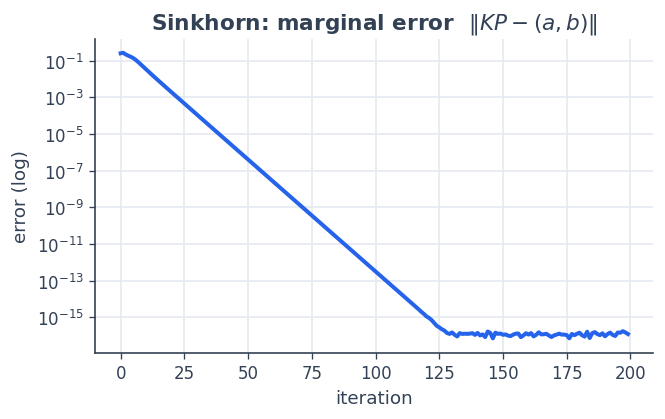

In [6]:
fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.semilogy(errors, color=BLUE)
ax.set_title("Sinkhorn: marginal error  $\\|K P - (a,b)\\|$")
ax.set_xlabel("iteration"); ax.set_ylabel("error (log)"); plt.show()

## 4 · The transport plan

The coupling sits between the two marginals. We display it with the **source on the horizontal
axis and the target on the vertical axis**, so the source marginal $a$ sits on top and the
target marginal $b$ runs up the right — each aligned with the axis it belongs to. Mass flows
from the single source bump to *both* target bumps.

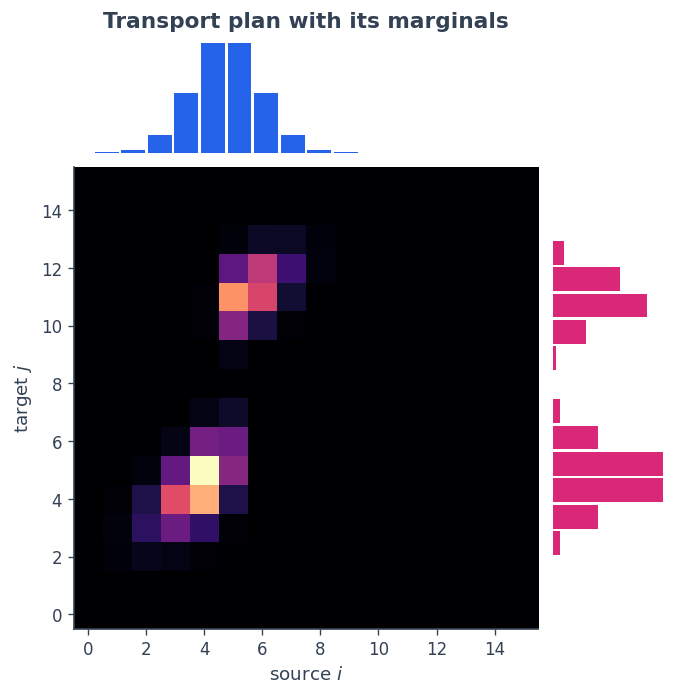

In [7]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(6.4, 6.4))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)
ax_top = fig.add_subplot(gs[0, 0]); ax_main = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

# transpose the plan so the x-axis is the source and the y-axis is the target
ax_main.imshow(P.T, cmap="magma", origin="lower", aspect="auto"); ax_main.grid(False)
ax_main.set_xlabel("source $i$"); ax_main.set_ylabel("target $j$")
ax_top.bar(np.arange(n), a, color=BLUE, width=0.9); ax_top.axis("off")       # source marginal
ax_top.set_title("Transport plan with its marginals")
ax_right.barh(np.arange(m), b, color=PINK, height=0.9); ax_right.axis("off") # target marginal
plt.show()

A second view makes the *movement* explicit: each ribbon connects a source bin to a target
bin, with width proportional to the transported mass $P_{ij}$.

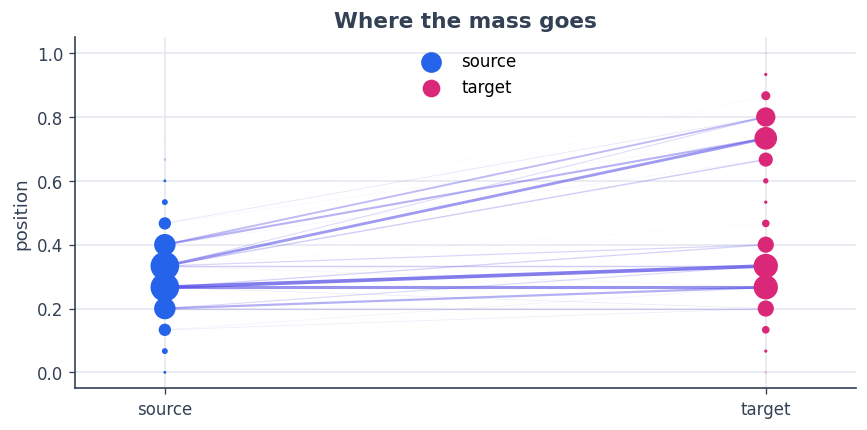

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 3.8))
Pn = P / P.max()
for i in range(n):
    for j in range(m):
        if Pn[i, j] > 0.02:
            ax.plot([0, 1], [xs[i], ys[j]], color=INDIGO,
                    alpha=float(min(Pn[i, j], 1.0)) * 0.7, lw=2.2 * Pn[i, j])
ax.scatter(np.zeros(n), xs, s=900 * a, color=BLUE, zorder=5, label="source")
ax.scatter(np.ones(m),  ys, s=900 * b, color=PINK, zorder=5, label="target")
ax.set_xlim(-0.15, 1.15); ax.set_xticks([0, 1]); ax.set_xticklabels(["source", "target"])
ax.set_ylabel("position"); ax.set_title("Where the mass goes"); ax.legend(loc="upper center")
plt.show()

## Recap

* The OT marginal constraint is a **linear operator** $K$; `MatrixFreeLinOp(apply, rapply, …)`
  captures it with two tiny functions and no stored matrix.
* `rapply` must be the **true adjoint** — here the broadcast/tiling map — and we checked the
  identity $\langle KP, g\rangle = \langle P, K^\*g\rangle$ numerically.
* That same adjoint is the workhorse inside Sinkhorn: it assembles the plan
  $P=\exp((K^\*[\phi,\psi]-C)/\varepsilon)$ from the dual potentials.

**Next:** [7 · Manifold descent](07_manifold_descent.ipynb) — optimisation with a genuinely
non-Euclidean geometry.